# M1: hue sensor, flashDiff/ exploration

`PLANhue.md` M1, Goal 3 in `hue_sensor_experiment_notes.md`: the same grid experiment, but which of red/green/yellow actually flashes changes per file -- isolating each channel's own contribution before relating any of this to `ssveps/`'s EEG responses. Nine conditions: `NN` (nothing, baseline check), `R`/`G`/`Y` (one channel alone), `RG`/`RY`/`GY` (two together), `RGY`/`RGY_1` (all three, two separate runs).

Exploration only (`PLANhue.md`): raw channel data in full, one trial's shape (the trial-boundary contamination `hue/README.md` documents shows up here too, just differently), a first per-trial aggregation, and the grid view for a few representative conditions.

In [1]:
import sys
sys.path.append('../scripts')

import pandas as pd

import loader
import plotting

df = loader.load_flashdiff()
df.groupby('condition').size()

condition
G        3618
GY       3618
NN       3618
R        3618
RG       3618
RGY      3618
RGY_1    3618
RY       3618
Y        3618
dtype: int64

## The whole channel data, completely

One panel per condition, every raw sample of `HueR`/`HueG`/`HueB` in recording order.

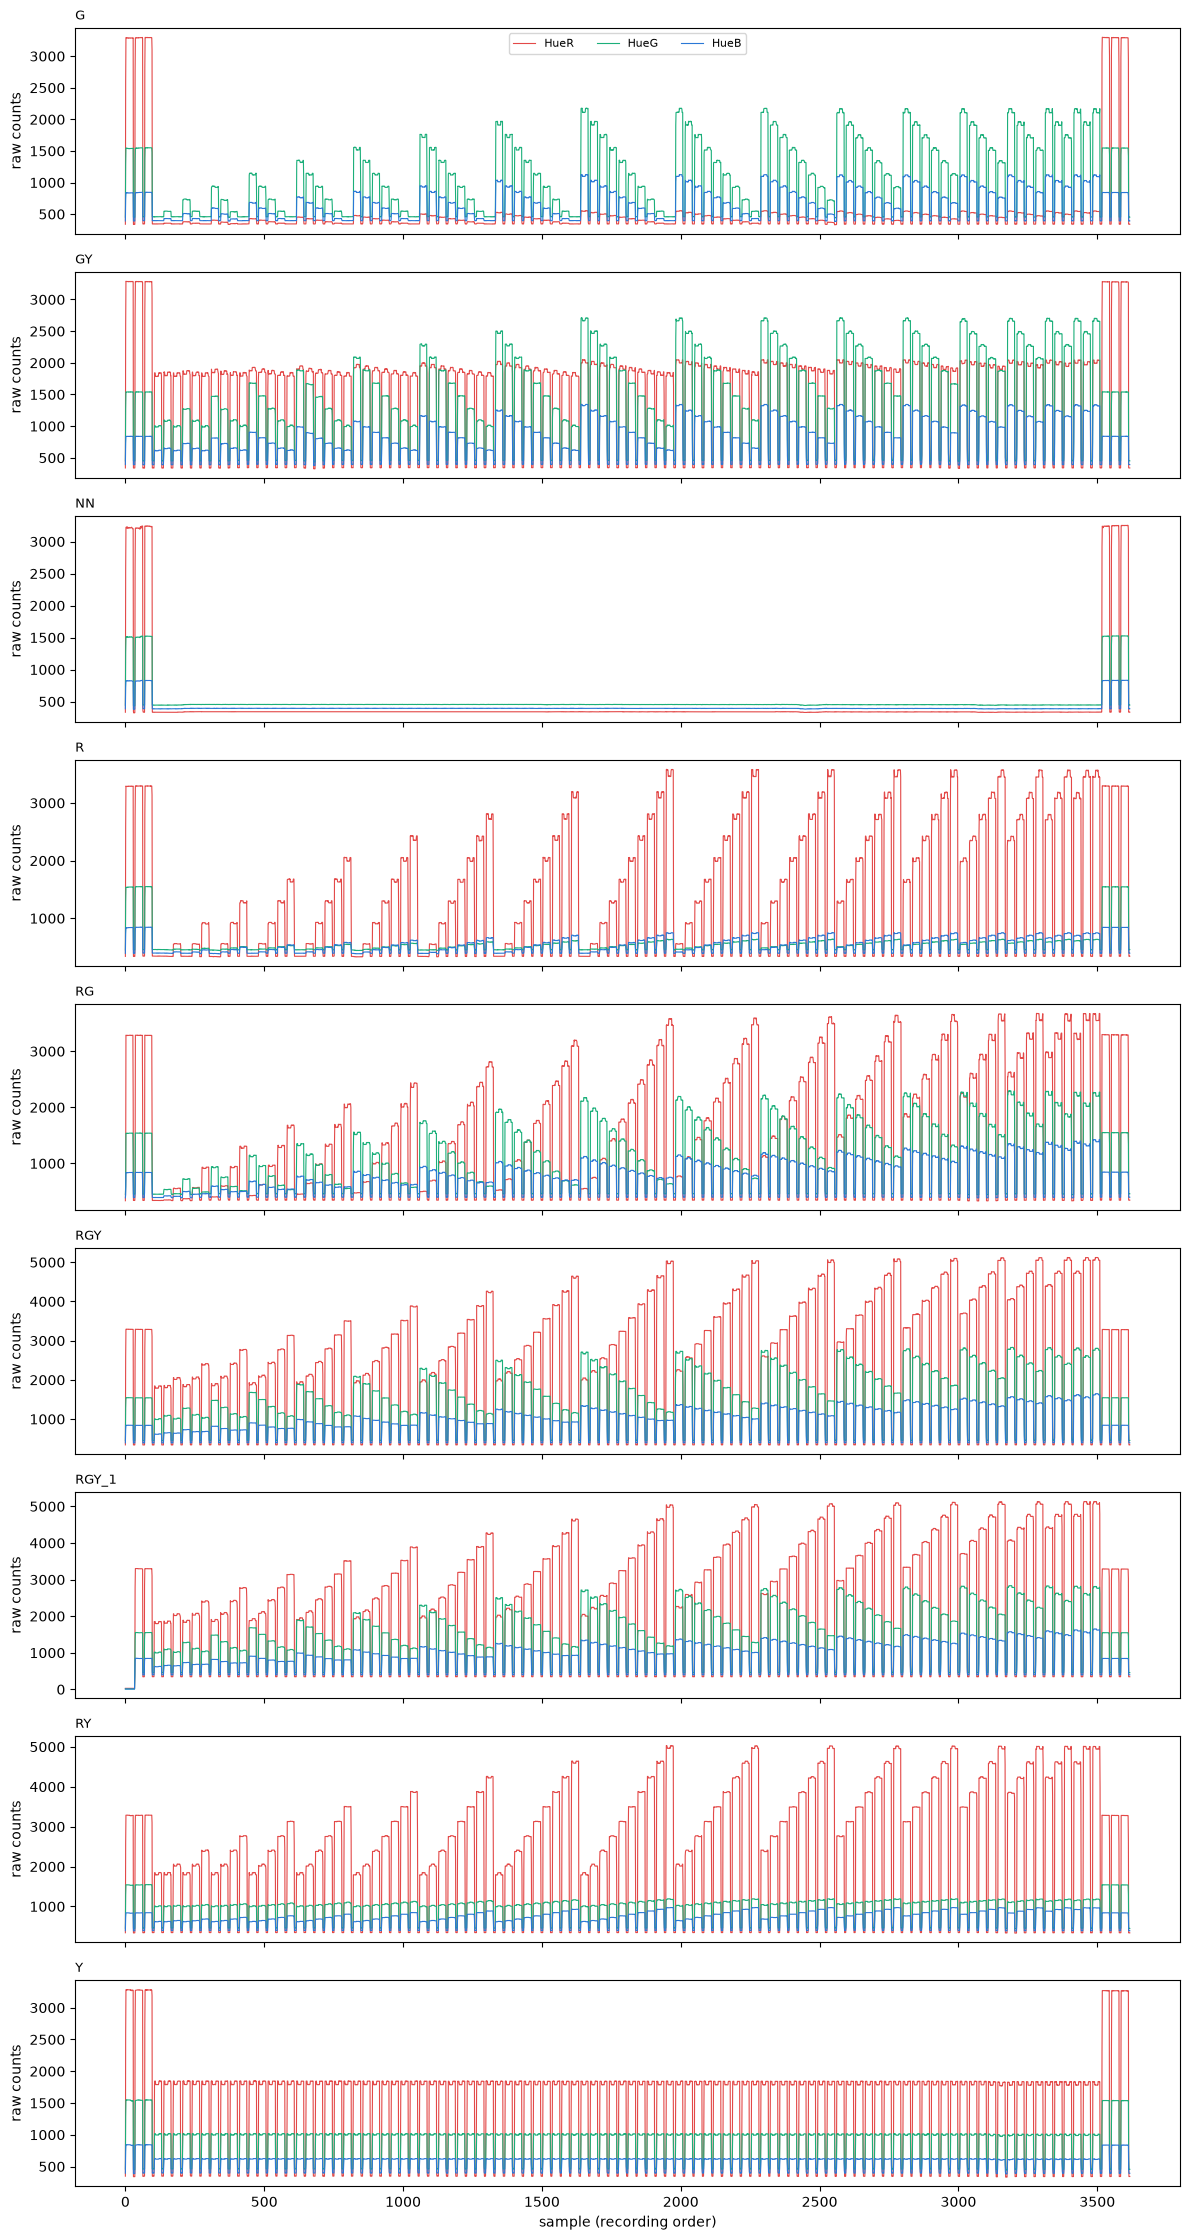

In [2]:
plotting.plot_channel_overview(df, group_col='condition');

Every panel shows a strong spike at the very start and end, regardless of condition -- including `NN`, where nothing should be flashing. These are the baseline blocks (`is_baseline=True`), framing the grid the same way `ssveps/`'s own baseline trials sit pre- and post-grid. Oddly, baseline rows' own `Red`/`Green`/`Yellow` columns all read `0` even while `HueR` reads ~3290 in the middle of the block -- whatever the baseline procedure actually flashes isn't captured in those columns. Worth asking about directly rather than guessing at it.

Within the grid portion: `NN` stays flat and low throughout -- the cleanest sanity check this dataset offers (nothing flashes, nothing changes). `Y` is flat and *elevated*, with almost no variation across the grid -- makes sense, since "flash at the yellow reference" doesn't depend on the grid's red/green value at all. `R`/`G` each show a response concentrated on their own channel; `RG`/`RY`/`GY`/`RGY`/`RGY_1` show progressively more combined structure as more channels actually flash.

## One trial, up close

`condition='R'` (only the red LED flashes) at the grid's strongest red cell (`Red=3200, Green=0`).

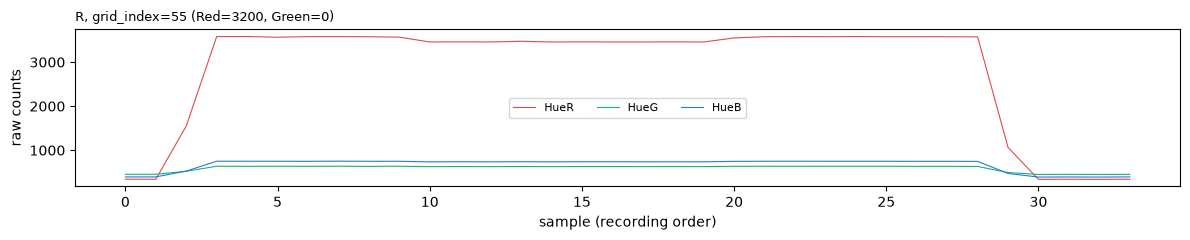

In [3]:
cond_r = df[df['condition'] == 'R']
grid_only = cond_r[~cond_r['is_baseline']]
strong_red_gi = grid_only.loc[(grid_only['Red'] == 3200) & (grid_only['Green'] == 0), 'grid_index'].iloc[0]
one_trial = grid_only[grid_only['grid_index'] == strong_red_gi].assign(condition=f"R, grid_index={int(strong_red_gi)} (Red=3200, Green=0)")
plotting.plot_channel_overview(one_trial, group_col='condition');

Same boundary-contamination issue `hue/README.md` documents for `filters/`, but manifesting the other way here: this trial's trailing edge drops sharply rather than overshooting, because `grid_index=56` (immediately next in the file) is `Red=355, Green=2000` -- much less red than this cell's 3200 -- so the transition leaks the *lower* neighbor's value in rather than spiking beyond both. Same underlying cause (the `Stim` label boundary doesn't land exactly on the physical LED transition), same fix either way: trim both edges before aggregating.

## Per-trial aggregation, reused from `01_filters_explore.ipynb`

Same `EDGE_TRIM`-based trim -- not promoted to `scripts/` yet (`PLANhue.md`).

In [4]:
EDGE_TRIM = 3

def aggregate_grid(condition_df, edge_trim=EDGE_TRIM):
    """Mean HueR/HueG/HueB per grid cell, dropping edge_trim samples from
    each end of every Stim block to exclude the transition overshoot at
    both edges (hue/README.md)."""
    grid = condition_df[~condition_df['is_baseline']]
    rows = []
    for (red, green), g in grid.groupby(['Red', 'Green']):
        g = g.sort_values('sample_idx')
        trimmed = g.iloc[edge_trim:-edge_trim] if len(g) > 2 * edge_trim else g
        rows.append({'Red': red, 'Green': green, 'HueR': trimmed['HueR'].mean(), 'HueG': trimmed['HueG'].mean(), 'HueB': trimmed['HueB'].mean(), 'n_samples': len(trimmed)})
    return pd.DataFrame(rows)

aggregates = {condition: aggregate_grid(sub) for condition, sub in df.groupby('condition')}
aggregates['R'].describe()

,Red,Green,HueR,HueG,HueB,n_samples
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,1599.600000,999.600000,1728.838300,530.515640,545.237106,28.130000
std,1026.353868,641.453715,953.883728,54.188476,105.196010,0.337998
min,0.000000,0.000000,332.821429,443.321429,386.500000,28.000000
25%,711.000000,444.000000,869.758929,482.762623,450.362069,28.000000
50%,1599.500000,999.500000,1698.071429,528.571429,541.928571,28.000000
75%,2488.000000,1555.000000,2582.071429,579.535714,639.732143,28.000000
max,3200.000000,2000.000000,3329.178571,620.750000,721.678571,29.000000


## The channel-perception grid, per condition

`NN` (nothing flashes -- should look flat/uninformative), `R` and `G` (one channel alone -- should each show a response tracking mostly their own axis), `RGY` (everything together).

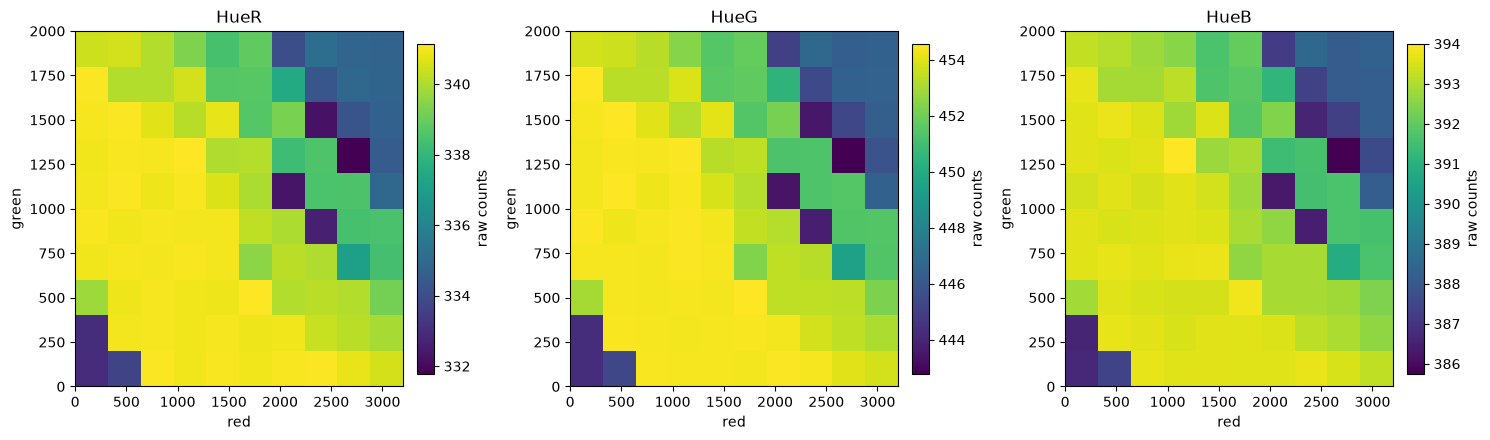

In [5]:
plotting.plot_channel_grid(aggregates['NN']);

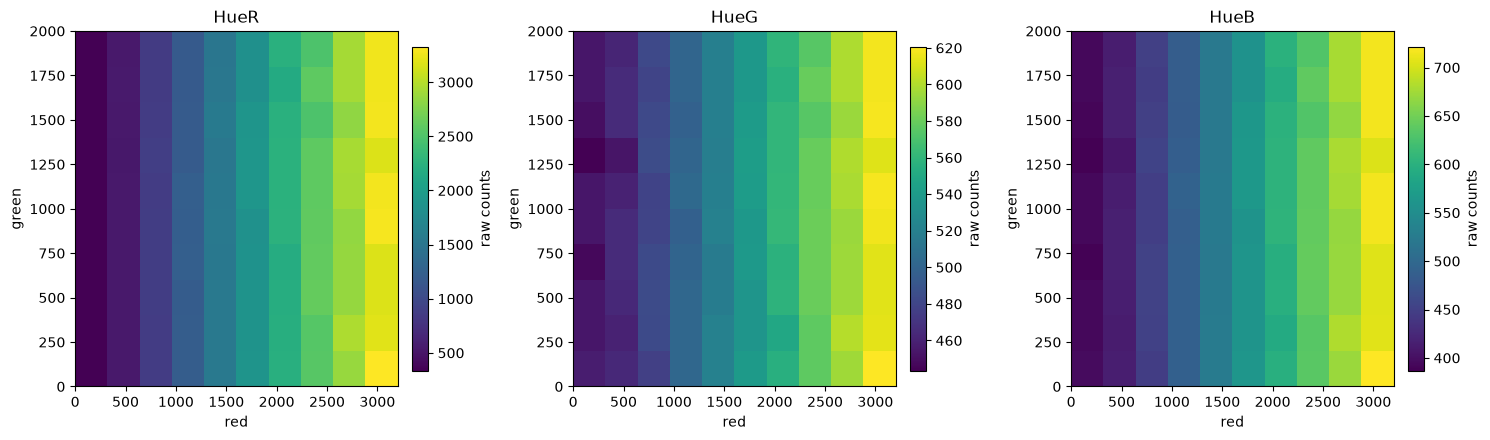

In [6]:
plotting.plot_channel_grid(aggregates['R']);

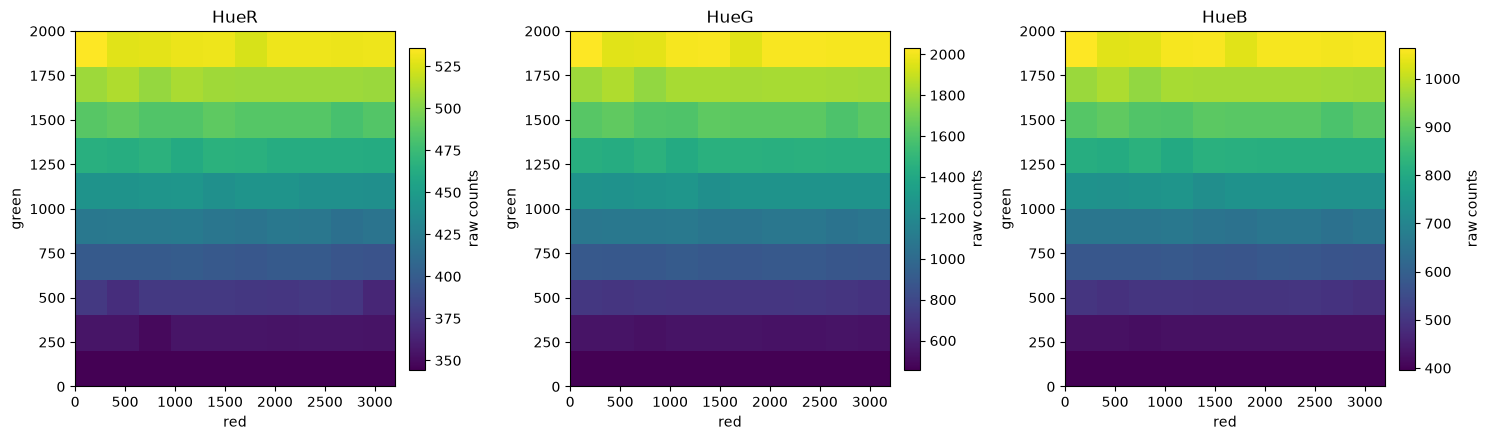

In [7]:
plotting.plot_channel_grid(aggregates['G']);

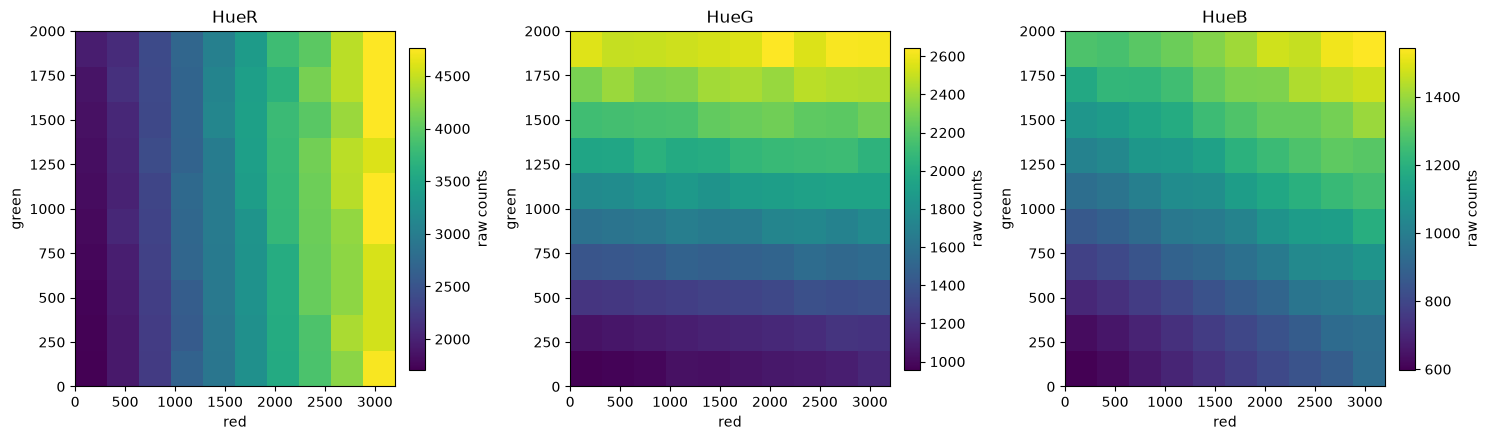

In [8]:
plotting.plot_channel_grid(aggregates['RGY']);

`NN`'s three panels are close to flat -- nothing flashing, nothing to see, as expected. `R`'s `HueR` panel tracks red almost purely (a clean left-to-right gradient, essentially flat top-to-bottom); `G`'s `HueG` panel is the same story rotated (a clean bottom-to-top gradient). That's the core validation this condition set is for: a single flashing channel isolates cleanly onto its own grid axis. There's real but small crosstalk -- `G`'s `HueB` panel rises noticeably with green too (400 to ~1050, a real secondary response), while `R`'s `HueG`/`HueB` panels barely move (a ~150-300-count range each) -- green-into-blue crosstalk looks more pronounced than red-into-green/blue here. `RGY` layers all three: `HueR` still tracks red, `HueG` still tracks green, and `HueB` picks up a mix of both, consistent with the crosstalk seen in `01_filters_explore.ipynb`'s grid too.

## The two RGY runs, compared

`RGY` and `RGY_1` are the same condition, logged twice, with different raw `Stim`-numbering schemes (`hue/README.md`) -- now normalized to the same `grid_index`, so they're directly comparable as a rough repeatability check.

In [9]:
compare = aggregates['RGY'].merge(aggregates['RGY_1'], on=['Red', 'Green'], suffixes=('_run1', '_run2'))
for channel in ['HueR', 'HueG', 'HueB']:
    diff = (compare[f'{channel}_run1'] - compare[f'{channel}_run2']).abs()
    print(f"{channel}: mean |run1 - run2| = {diff.mean():.1f}, max = {diff.max():.1f}")

HueR: mean |run1 - run2| = 18.7, max = 121.2
HueG: mean |run1 - run2| = 7.6, max = 73.4
HueB: mean |run1 - run2| = 3.1, max = 38.3


Small, not zero: mean channel differences between the two RGY runs are 3-19 counts (a few percent of each channel's typical range), with the worst single-cell disagreement around 120 on `HueR`. Reasonable repeatability for a bench sensor -- and a useful number to keep in mind before trusting any small effect out of this aggregation: differences smaller than this can't yet be distinguished from run-to-run noise.

## Not yet: the additivity hypothesis

`hue_sensor_experiment_notes.md`'s working hypothesis (`GY \u2248 G + Y (+ NN)`, `RGY \u2248 R + G + Y (+ NN)`, or various sub-combinations) is explicitly something to check *before* relating any of this to the SSVEP data -- but that's a real analysis, not exploration, so it's next-milestone work (`PLANhue.md`), once the aggregation above is settled rather than still being trimmed by eye.